In [ ]:
#conda activate burnseverity
import pandas as pd
import geopandas as gpd
import requests
import rasterio as rio
from matplotlib import pyplot as plt
from rasterio.plot import show_hist
import numpy as np
from rasterio.warp import calculate_default_transform, reproject, Resampling
import validation as val



/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: California_Fire_Perimeters_(all).shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


### Validation goals

#### Questions
1. Difference between our dNBR and dNBR from BAIR?
2. Are the two different indices truly different in our tool and is ours truly more sensitive?
3. Do our boundaries and those from CalFire match?
4. Sensitivity around chosen time windows?

#### Metrics
1. Recoarse Sentinel to Landsat, $R^2$
2. $var(dNBR) < var(RBR)$
3. Percent overlap
4. Before period fixed through three weeks. After ${5, 10, 15, 21, 30, 45, 60, 90}$. Criteria: stable and low variance 


In [61]:
fires = pd.read_csv('fire_processing_jobs.csv')
fire_event_name = "COFFEE POT_2024-08-03_30"
job_id = fires.loc[fires['fire_event_name'] == fire_event_name, 'job_id'].values[0]
test = requests.get(f"https://fire-recovery-backend-dev-113009620257.us-central1.run.app/fire-recovery/result/analyze_fire_severity/{fire_event_name}/{job_id}")

print(test.json())

{'fire_event_name': 'COFFEE POT_2024-08-03_30', 'status': 'complete', 'job_id': 'a269a19f-a8ee-49e7-80d9-836497cf96fe', 'coarse_severity_cog_urls': {'rbr': 'https://storage.googleapis.com/fire-recovery-store/assets/a269a19f-a8ee-49e7-80d9-836497cf96fe/fire_severity/rbr.tif', 'dnbr': 'https://storage.googleapis.com/fire-recovery-store/assets/a269a19f-a8ee-49e7-80d9-836497cf96fe/fire_severity/dnbr.tif', 'rdnbr': 'https://storage.googleapis.com/fire-recovery-store/assets/a269a19f-a8ee-49e7-80d9-836497cf96fe/fire_severity/rdnbr.tif'}}


In [65]:
fires = pd.read_csv('fire_processing_jobs.csv')
calfire = gpd.read_file('California_Fire_Perimeters_(all).shp')
fire_name = 'COFFEE POT'
fire_days = 5
fire_polygon = calfire[calfire['FIRE_NAME'] == fire_name].to_crs(epsg=4326)

# Filter by both fire_name and post_fire_days
fire_event_name = fires.loc[(fires['fire_name'] == fire_name) & (fires['post_fire_days'] == fire_days), 'fire_event_name'].values[0]
job_id = fires.loc[fires['fire_event_name'] == fire_event_name, 'job_id'].values[0]

test = requests.get(f"https://fire-recovery-backend-dev-113009620257.us-central1.run.app/fire-recovery/result/analyze_fire_severity/{fire_event_name}/{job_id}")

print(test.json())

/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: California_Fire_Perimeters_(all).shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


{'fire_event_name': 'COFFEE POT_2024-08-03_5', 'status': 'complete', 'job_id': '573421be-412c-403d-9d72-b591de886c43', 'coarse_severity_cog_urls': {'rbr': 'https://storage.googleapis.com/fire-recovery-store/assets/573421be-412c-403d-9d72-b591de886c43/fire_severity/rbr.tif', 'dnbr': 'https://storage.googleapis.com/fire-recovery-store/assets/573421be-412c-403d-9d72-b591de886c43/fire_severity/dnbr.tif', 'rdnbr': 'https://storage.googleapis.com/fire-recovery-store/assets/573421be-412c-403d-9d72-b591de886c43/fire_severity/rdnbr.tif'}}


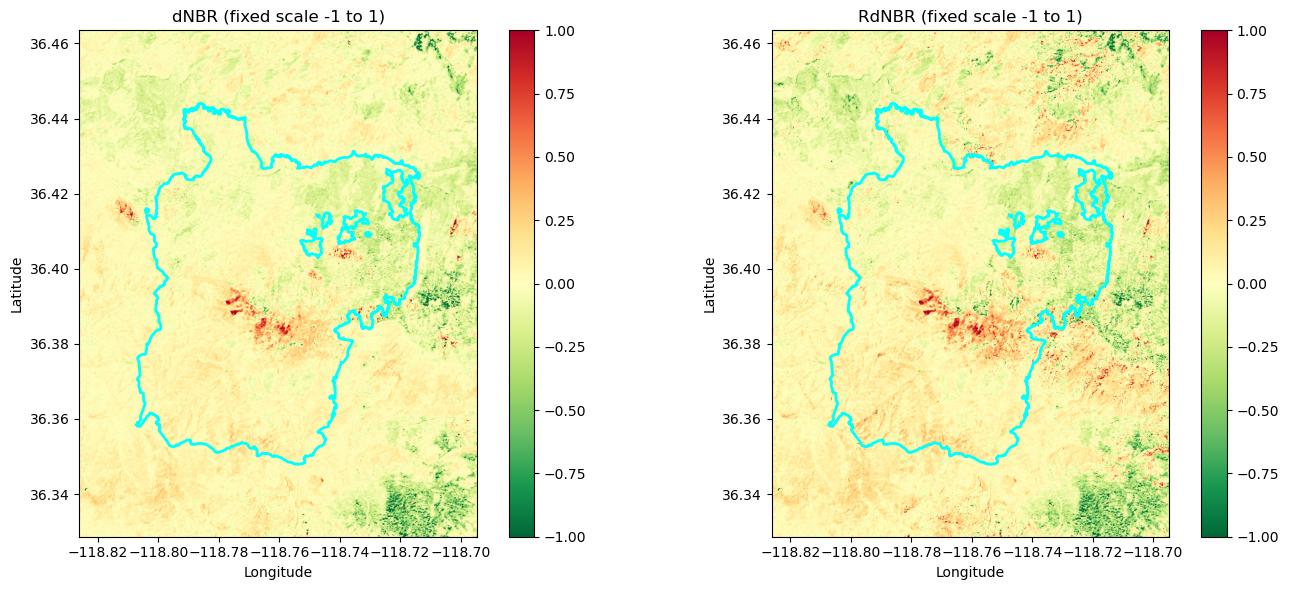

In [ ]:
def plot_fire(fire_name, fire_days, fire_polygon):
    fire_event_name = fires.loc[(fires['fire_name'] == fire_name) & (fires['post_fire_days'] == fire_days), 'fire_event_name'].values[0]
    job_id = fires.loc[fires['fire_event_name'] == fire_event_name, 'job_id'].values[0]

    request = requests.get(f"https://fire-recovery-backend-dev-113009620257.us-central1.run.app/fire-recovery/result/analyze_fire_severity/{fire_event_name}/{job_id}")

    urls = request.json().get('coarse_severity_cog_urls')
    dnbr_url = urls.get('dnbr')
    rdnbr_url = urls.get('rdnbr')

    # Reproject dNBR to lat/lon
    with rio.open(dnbr_url) as src:
        transform, width, height = calculate_default_transform(
            src.crs, 'EPSG:4326', src.width, src.height, *src.bounds)
        
        dnbr_reproj = np.empty((height, width), dtype=src.dtypes[0])
        
        reproject(
            source=rio.band(src, 1),
            destination=dnbr_reproj,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs='EPSG:4326',
            resampling=Resampling.bilinear)
        
        # Get extent for plotting
        bounds = rio.transform.array_bounds(height, width, transform)
        dnbr_extent = [bounds[0], bounds[2], bounds[1], bounds[3]]  # [left, right, bottom, top]

    # Reproject RdNBR to lat/lon
    with rio.open(rdnbr_url) as src:
        transform, width, height = calculate_default_transform(
            src.crs, 'EPSG:4326', src.width, src.height, *src.bounds)
        
        rdnbr_reproj = np.empty((height, width), dtype=src.dtypes[0])
        
        reproject(
            source=rio.band(src, 1),
            destination=rdnbr_reproj,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs='EPSG:4326',
            resampling=Resampling.bilinear)
        
        rdnbr_extent = [bounds[0], bounds[2], bounds[1], bounds[3]]

    # Plot reprojected rasters with polygon overlay (fixed color scale)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Fixed color scale for comparison across fires
    vmin, vmax = -1, 1

    # dNBR
    im1 = axes[0].imshow(dnbr_reproj, cmap='RdYlGn_r', vmin=vmin, vmax=vmax, 
                        extent=dnbr_extent, origin='upper', zorder=1)
    fire_polygon.boundary.plot(ax=axes[0], color='cyan', linewidth=2, zorder=2)
    axes[0].set_xlim(dnbr_extent[0], dnbr_extent[1])
    axes[0].set_ylim(dnbr_extent[2], dnbr_extent[3])
    axes[0].set_title(f'dNBR ({fire_event_name})')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    plt.colorbar(im1, ax=axes[0])

# RdNBR
im2 = axes[1].imshow(rdnbr_reproj, cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
                     extent=rdnbr_extent, origin='upper', zorder=1)
fire_polygon.boundary.plot(ax=axes[1], color='cyan', linewidth=2, zorder=2)
axes[1].set_xlim(rdnbr_extent[0], rdnbr_extent[1])
axes[1].set_ylim(rdnbr_extent[2], rdnbr_extent[3])
axes[1].set_title(f'RdNBR ({fire_event_name})')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()